# 04d — CLEAR Peptide Oracle Training

## Obiettivo

Questo notebook addestra l'oracolo surrogato differenziabile che verrà usato da CLEAR per ottimizzare il peptide:

```text
F0010 — IGERCQYRDLK
```

Input principale:

```text
outputs/clear_local_peptide_dataset_04c/
    clear_local_peptide_variant_dataset_labeled.csv
```

Il notebook:

1. controlla qualità e distribuzione del dataset;
2. definisce il target dell'oracolo;
3. crea split train/validation/test con riduzione del leakage;
4. costruisce una rappresentazione a grafo lineare del peptide;
5. confronta baseline semplici;
6. addestra una GNN differenziabile senza PyTorch Geometric;
7. valuta regressione e capacità di riconoscere varianti migliori del seed;
8. salva modello, scaler, split, predizioni e configurazione;
9. produce gli artefatti necessari al notebook 04e CLEAR.

L'oracolo non sostituisce FoldX o Rosetta: fornisce a CLEAR una funzione rapida e differenziabile da ottimizzare localmente.

## 1. Dipendenze

```bash
pip install pandas numpy matplotlib scikit-learn scipy torch joblib
```

In [2]:
from pathlib import Path
import json, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import pearsonr, spearmanr
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",180)
pd.set_option("display.max_colwidth",180)
print("PyTorch:",torch.__version__)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


PyTorch: 2.2.1
Device: mps


## 2. Configurazione

In [4]:
RANDOM_SEED=20260806
SEED_SEQUENCE="IGERCQYRDLK"
SEQUENCE_LENGTH=len(SEED_SEQUENCE)
AA_ALPHABET=list("ACDEFGHIKLMNPQRSTVWY")
AA_TO_INDEX={aa:i for i,aa in enumerate(AA_ALPHABET)}
OUTPUT_DIR=Path("outputs")
DATASET_04C_DIR=OUTPUT_DIR/"clear_local_peptide_dataset_04c"
LABELED_DATASET_CSV=DATASET_04C_DIR/"clear_local_peptide_variant_dataset_labeled.csv"
FULL_DATASET_CSV=DATASET_04C_DIR/"clear_local_peptide_variant_dataset.csv"
POSITION_CONSTRAINTS_CSV=DATASET_04C_DIR/"library"/"clear_position_constraints.csv"
ORACLE_DIR=OUTPUT_DIR/"clear_peptide_oracle_04d"
MODEL_DIR=ORACLE_DIR/"models"
REPORT_DIR=ORACLE_DIR/"reports"
for d in [ORACLE_DIR,MODEL_DIR,REPORT_DIR]: d.mkdir(parents=True,exist_ok=True)
PRIMARY_TARGET_PREFERENCE=["oracle_target_composite_preliminary","foldx_ddG_total_kcal_mol"]
TEST_SIZE=0.20
VALID_SIZE_WITHIN_REMAINING=0.20
BATCH_SIZE=64
LEARNING_RATE=1e-3
WEIGHT_DECAY=1e-5
MAX_EPOCHS=300
EARLY_STOPPING_PATIENCE=30
HIDDEN_DIM=64
MESSAGE_PASSING_STEPS=3
DROPOUT=0.20
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print("Input:",LABELED_DATASET_CSV.resolve())
print("Output:",ORACLE_DIR.resolve())
print("Device:",DEVICE)

Device: mps
Input: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv
Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d
Device: mps


## 3. Caricamento del dataset

In [5]:
dataset_path=LABELED_DATASET_CSV if LABELED_DATASET_CSV.exists() else FULL_DATASET_CSV
if not dataset_path.exists(): raise FileNotFoundError("Dataset 04c non trovato. Eseguire prima il notebook 04c.")
df=pd.read_csv(dataset_path)
required={"variant_id","sequence","variant_type","n_mutations","mutation_labels","mutated_sequence_positions"}
missing=required-set(df.columns)
if missing: raise ValueError("Colonne mancanti: "+", ".join(sorted(missing)))
print("Righe caricate:",len(df))
display(df.head(10))

Righe caricate: 539


,variant_id,variant_type,sequence,n_mutations,mutation_labels,foldx_mutation_string,mutated_sequence_positions,mutated_resseqs,n_mutated_hotspots,all_mutations_conservative,filter_status,passes_filters,net_charge_proxy,hydrophobic_fraction,aromatic_fraction,polar_fraction,positive_fraction,negative_fraction,glycine_count,proline_count,cysteine_count,max_identical_run,hamming_distance_from_seed,chunk_id,foldx_ddG_total_kcal_mol,foldx_energy_parse_status,foldx_raw_line,variant_model_pdb,model_status,structural_parse_status,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_hotspots_in_contact,min_interchain_distance_A,n_atom_clashes_lt_2A,norm_favorable_foldx_ddG,norm_native_contact_recall,norm_hotspot_preservation,clash_penalty,oracle_target_composite_preliminary,has_complete_foldx_label
0,V00000,seed,IGERCQYRDLK,0,NaN,NaN,NaN,NaN,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,0,NaN,0.000000,SEED_REFERENCE,NaN,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb,SEED_REFERENCE,SEED_REFERENCE,185.0,37.0,10.0,0.909091,1.000000,1.000000,1.0,6.0,2.602119,0.0,0.717263,1.000,0.5,0.0,0.758631,True
1,V00001,single,AGERCQYRDLK,1,I1A,ID38A;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.463630,PARSED_BY_ORDER,F0010_native_complex_1.pdb\t0.46363\t0.346148\t1.02638\t0.711639\t-0.416927\t-1.00581\t0.999032\t0.0861055\t-1.51489\t0.265597\t0\t0\t0\t-0.0911063\t0.138896\t-0.0210033\t0\t0\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00001.pdb,MODEL_AVAILABLE,OK,173.0,35.0,10.0,0.909091,0.945946,1.000000,1.0,6.0,2.602119,0.0,0.654662,0.750,0.5,0.0,0.652331,True
2,V00002,single,FGERCQYRDLK,1,I1F,ID38F;,1,38,0,False,PASS,True,1,0.272727,0.181818,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.371447,PARSED_BY_ORDER,F0010_native_complex_2.pdb\t0.371447\t0.377605\t1.05869\t-0.181123\t0.49995\t-0.258039\t-0.429134\t-0.0251336\t-0.587722\t0.0633776\t0\t0\t0\t-0.144454\t-0.116356\t-0.00272559\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00002.pdb,MODEL_AVAILABLE,OK,197.0,37.0,10.0,0.909091,0.945946,0.945946,1.0,6.0,2.602119,0.0,0.667109,0.750,0.5,0.0,0.658555,True
3,V00003,single,LGERCQYRDLK,1,I1L,ID38L;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,-0.033391,PARSED_BY_ORDER,F0010_native_complex_3.pdb\t-0.0333914\t-0.279508\t-0.300106\t-0.533883\t0.513429\t1.1222\t-0.527678\t0.181744\t0.355015\t-0.0665884\t0\t0\t0\t-0.502683\t0.17036\t0.00555312\t0...,outputs/clear_local_peptide_dataset_04c/variant_models/V00003.pdb,MODEL_AVAILABLE,OK,191.0,38.0,10.0,0.909091,0.972973,0.947368,1.0,6.0,2.602119,0.0,0.721772,0.875,0.5,0.0,0.723386,True
4,V00004,single,MGERCQYRDLK,1,I1M,ID38M;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,-0.310250,PARSED_BY_ORDER,F0010_native_complex_4.pdb\t-0.31025\t-0.0172325\t-0.0104792\t-0.551273\t0.110236\t0.617606\t-0.634628\t0.0257439\t0.639171\t0.195687\t0\t0\t0\t-0.713999\t0.148453\t0.00342027\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00004.pdb,MODEL_AVAILABLE,OK,175.0,37.0,10.0,0.909091,0.972973,0.972973,1.0,6.0,2.602119,0.0,0.759154,0.875,0.5,0.0,0.742077,True
5,V00005,single,TGERCQYRDLK,1,I1T,ID38T;,1,38,0,True,PASS,True,1,0.181818,0.090909,0.181818,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.200212,PARSED_BY_ORDER,F0010_native_complex_5.pdb\t0.200212\t-0.169938\t-0.786697\t0.844637\t0.011369\t-1.01028\t1.43161\t-0.0578912\t-0.0350143\t-0.0505245\t0\t0\t0\t0.0308112\t-0.0699397\t0\t0\t0\t...,outputs/clear_local_peptide_dataset_04c/variant_models/V00005.pdb,MODEL_AVAILABLE,OK,190.0,38.0,10.0,0.909091,1.000000,0.973684,1.0,6.0,2.602119,0.0,0.690230,1.000,0.5,0.0,0.745115,True
6,V00006,single,VGERCQYRDLK,1,I1V,ID38V;,1,38,0,True,PASS,True,1,0.272

## 4. Selezione del target

Viene preferito `oracle_target_composite_preliminary`; in alternativa viene usato `foldx_ddG_total_kcal_mol`.

In [6]:
TARGET_COLUMN=None
for candidate in PRIMARY_TARGET_PREFERENCE:
    if candidate in df.columns and df[candidate].notna().sum()>=20:
        TARGET_COLUMN=candidate; break
if TARGET_COLUMN is None: raise ValueError("Nessun target disponibile con label sufficienti.")
HIGHER_IS_BETTER=(TARGET_COLUMN=="oracle_target_composite_preliminary")
df=df[df[TARGET_COLUMN].notna()].copy()
df[TARGET_COLUMN]=pd.to_numeric(df[TARGET_COLUMN],errors="coerce")
df=df[df[TARGET_COLUMN].notna()].reset_index(drop=True)
print("Target:",TARGET_COLUMN)
print("Higher is better:",HIGHER_IS_BETTER)
print("Righe utilizzabili:",len(df))

Target: oracle_target_composite_preliminary
Higher is better: True
Righe utilizzabili: 539


## 5. Controlli di qualità

In [7]:
quality_summary=pd.DataFrame({"metric":["n_rows","n_unique_sequences","n_seed","n_single","n_double","duplicate_sequences","wrong_sequence_length"],"value":[len(df),df.sequence.nunique(),int((df.variant_type=="seed").sum()),int((df.variant_type=="single").sum()),int((df.variant_type=="double").sum()),int(df.sequence.duplicated().sum()),int((df.sequence.str.len()!=SEQUENCE_LENGTH).sum())]})
display(quality_summary)
if df.sequence.duplicated().any(): raise ValueError("Sequenze duplicate presenti.")
if not df.sequence.str.len().eq(SEQUENCE_LENGTH).all(): raise ValueError("Lunghezze inattese.")
display(df[TARGET_COLUMN].describe())

,metric,value
0,n_rows,539
1,n_unique_sequences,539
2,n_seed,1
3,n_single,38
4,n_double,500
5,duplicate_sequences,0
6,wrong_sequence_length,0


count    539.000000
mean       0.608728
std        0.126187
min        0.200197
25%        0.536658
50%        0.629244
75%        0.700094
max        0.848590
Name: oracle_target_composite_preliminary, dtype: float64

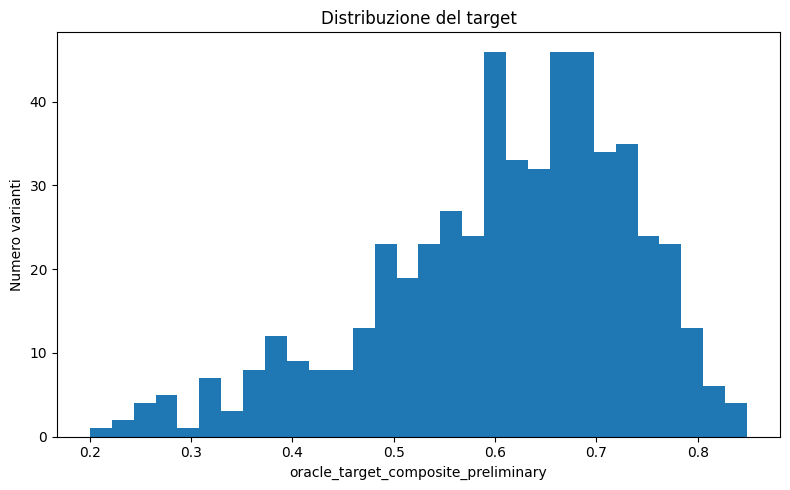

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df[TARGET_COLUMN],bins=30)
plt.xlabel(TARGET_COLUMN); plt.ylabel("Numero varianti"); plt.title("Distribuzione del target")
plt.tight_layout(); plt.savefig(REPORT_DIR/"target_distribution.png",dpi=300,bbox_inches="tight"); plt.show()

## 6. Soglia “migliore del seed”

In [9]:
seed_rows=df[df.sequence==SEED_SEQUENCE]
if seed_rows.empty: raise ValueError("Seed non presente nel dataset.")
SEED_TARGET_VALUE=float(seed_rows.iloc[0][TARGET_COLUMN])
df["is_better_than_seed"]=(df[TARGET_COLUMN]>SEED_TARGET_VALUE) if HIGHER_IS_BETTER else (df[TARGET_COLUMN]<SEED_TARGET_VALUE)
print("Target seed:",SEED_TARGET_VALUE)
print("Migliori del seed:",int(df.is_better_than_seed.sum()),"/",len(df))

Target seed: 0.7586314868473996
Migliori del seed: 50 / 539


## 7. Vincoli posizionali

In [10]:
if POSITION_CONSTRAINTS_CSV.exists():
    position_constraints=pd.read_csv(POSITION_CONSTRAINTS_CSV)
else:
    position_constraints=pd.DataFrame({"sequence_position_1based":np.arange(1,SEQUENCE_LENGTH+1),"is_hotspot":False,"position_class":"unknown"})
position_constraints["sequence_position_1based"]=pd.to_numeric(position_constraints["sequence_position_1based"],errors="raise").astype(int)
display(position_constraints)

,sequence_position_1based,chain,resseq,wildtype_aa,is_hotspot,alanine_scan_ddG_kcal_mol,position_class,allowed_substitutions,n_allowed_substitutions
0,1,D,38,I,False,1.419390,mutable_non_hotspot,AFLMTV,6
1,2,D,39,G,True,5.876590,protected_hotspot,NaN,0
2,3,D,40,E,False,1.489250,mutable_non_hotspot,DKNQR,5
3,4,D,41,R,True,5.734550,protected_hotspot,NaN,0
4,5,D,42,C,False,NaN,mutable_non_hotspot,ST,2
5,6,D,43,Q,True,2.515570,conservative_hotspot,ENRT,4
6,7,D,44,Y,True,3.370680,conservative_hotspot,FHTW,4
7,8,D,45,R,True,2.002810,conservative_hotspot,HKQ,3
8,9,D,46,D,False,0.017737,mutable_non_hotspot,ENQ,3
9,10,D,47,L,True,3.543710,conservative_hotspot,AFIMTV,6


## 8. Split anti-leakage

Le varianti che modificano lo stesso insieme di posizioni restano nello stesso split.

In [11]:
def normalize_group(value,variant_type):
    if variant_type=="seed": return "seed"
    text=str(value).strip()
    if not text or text.lower()=="nan": return "unknown"
    positions=sorted({int(tok) for tok in __import__('re').findall(r"\d+",text)})
    return ";".join(map(str,positions))
df["split_group"]=df.apply(lambda r: normalize_group(r["mutated_sequence_positions"],r["variant_type"]),axis=1)
indices=np.arange(len(df)); groups=df.split_group.values
gss_test=GroupShuffleSplit(n_splits=1,test_size=TEST_SIZE,random_state=RANDOM_SEED)
train_val_idx,test_idx=next(gss_test.split(indices,groups=groups))
train_val_df=df.iloc[train_val_idx].copy(); test_df=df.iloc[test_idx].copy()
gss_val=GroupShuffleSplit(n_splits=1,test_size=VALID_SIZE_WITHIN_REMAINING,random_state=RANDOM_SEED+1)
train_local,val_local=next(gss_val.split(np.arange(len(train_val_df)),groups=train_val_df.split_group.values))
train_df=train_val_df.iloc[train_local].copy(); val_df=train_val_df.iloc[val_local].copy()
split_sets={"train":train_df,"validation":val_df,"test":test_df}
split_summary=pd.DataFrame([{"split":n,"n_rows":len(p),"n_groups":p.split_group.nunique(),"n_better_than_seed":int(p.is_better_than_seed.sum()),"target_mean":p[TARGET_COLUMN].mean(),"target_std":p[TARGET_COLUMN].std()} for n,p in split_sets.items()])
display(split_summary)
assert not(set(train_df.split_group)&set(val_df.split_group))
assert not(set(train_df.split_group)&set(test_df.split_group))
assert not(set(val_df.split_group)&set(test_df.split_group))
print("Nessun gruppo condiviso tra gli split.")

,split,n_rows,n_groups,n_better_than_seed,target_mean,target_std
0,train,306,25,27,0.604141,0.134905
1,validation,112,7,13,0.643125,0.091603
2,test,121,8,10,0.588488,0.125695


Nessun gruppo condiviso tra gli split.


## 9. Feature amminoacidiche

In [12]:
AA_PROPERTIES={"A":[1.8,88.6,0,0,0],"C":[2.5,108.5,0,0,0],"D":[-3.5,111.1,-1,1,0],"E":[-3.5,138.4,-1,1,0],"F":[2.8,189.9,0,0,1],"G":[-0.4,60.1,0,0,0],"H":[-3.2,153.2,0.1,1,1],"I":[4.5,166.7,0,0,0],"K":[-3.9,168.6,1,1,0],"L":[3.8,166.7,0,0,0],"M":[1.9,162.9,0,0,0],"N":[-3.5,114.1,0,1,0],"P":[-1.6,112.7,0,0,0],"Q":[-3.5,143.8,0,1,0],"R":[-4.5,173.4,1,1,0],"S":[-0.8,89.0,0,1,0],"T":[-0.7,116.1,0,1,0],"V":[4.2,140.0,0,0,0],"W":[-0.9,227.8,0,0,1],"Y":[-1.3,193.6,0,1,1]}
property_matrix=np.array([AA_PROPERTIES[a] for a in AA_ALPHABET],dtype=np.float32)
property_mean=property_matrix.mean(0); property_std=property_matrix.std(0); property_std[property_std==0]=1
position_feature_rows=[]
for position in range(1,SEQUENCE_LENGTH+1):
    row=position_constraints[position_constraints.sequence_position_1based==position]
    if row.empty: vals=[0.,0.,0.]
    else:
        rec=row.iloc[0]; pc=str(rec.get("position_class","")); vals=[float(bool(rec.get("is_hotspot",False))),float(pc=="protected_hotspot"),float(pc=="conservative_hotspot")]
    position_feature_rows.append([position/SEQUENCE_LENGTH,*vals])
position_features=np.array(position_feature_rows,dtype=np.float32)
NODE_FEATURE_DIM=len(AA_ALPHABET)+property_matrix.shape[1]+position_features.shape[1]
print("Feature nodo:",NODE_FEATURE_DIM)

Feature nodo: 29


## 10. Codifica a grafo lineare

In [13]:
def encode_sequence(sequence):
    feats=[]
    for pos,aa in enumerate(sequence):
        one=np.zeros(len(AA_ALPHABET),dtype=np.float32); one[AA_TO_INDEX[aa]]=1
        prop=(np.array(AA_PROPERTIES[aa],dtype=np.float32)-property_mean)/property_std
        feats.append(np.concatenate([one,prop,position_features[pos]]))
    return np.stack(feats)
def make_chain_adjacency(length):
    A=np.eye(length,dtype=np.float32)
    for i in range(length-1): A[i,i+1]=A[i+1,i]=1
    d=A.sum(1,keepdims=True); inv=np.power(d,-0.5)
    return inv*A*inv.T
CHAIN_ADJACENCY=make_chain_adjacency(SEQUENCE_LENGTH)
print(encode_sequence(SEED_SEQUENCE).shape,CHAIN_ADJACENCY.shape)

(11, 29) (11, 11)


## 11. Baseline

In [14]:
def flattened_features(frame): return np.stack([encode_sequence(s).reshape(-1) for s in frame.sequence])
X_train_flat=flattened_features(train_df); X_val_flat=flattened_features(val_df); X_test_flat=flattened_features(test_df)
y_train_raw=train_df[TARGET_COLUMN].values.astype(np.float32); y_val_raw=val_df[TARGET_COLUMN].values.astype(np.float32); y_test_raw=test_df[TARGET_COLUMN].values.astype(np.float32)
target_scaler=StandardScaler(); target_scaler.fit(y_train_raw.reshape(-1,1))
def regression_metrics(y_true,y_pred):
    out={"MAE":mean_absolute_error(y_true,y_pred),"RMSE":math.sqrt(mean_squared_error(y_true,y_pred)),"R2":r2_score(y_true,y_pred)}
    out["Pearson"]=pearsonr(y_true,y_pred)[0] if len(np.unique(y_true))>1 else np.nan
    out["Spearman"]=spearmanr(y_true,y_pred)[0] if len(np.unique(y_true))>1 else np.nan
    return out
baseline_models={"Ridge":Pipeline([("scaler",StandardScaler()),("model",Ridge(alpha=1.0))]),"RandomForest":RandomForestRegressor(n_estimators=400,min_samples_leaf=2,random_state=RANDOM_SEED,n_jobs=-1)}
rows=[]
for name,mdl in baseline_models.items():
    mdl.fit(X_train_flat,y_train_raw)
    for split,X,y in [("validation",X_val_flat,y_val_raw),("test",X_test_flat,y_test_raw)]:
        m=regression_metrics(y,mdl.predict(X)); m.update({"model":name,"split":split}); rows.append(m)
baseline_results_df=pd.DataFrame(rows); display(baseline_results_df)

,MAE,RMSE,R2,Pearson,Spearman,model,split
0,0.048672,0.063949,0.508254,0.716515,0.708451,Ridge,validation
1,0.039129,0.052129,0.826573,0.919577,0.910615,Ridge,test
2,0.061898,0.079413,0.241666,0.532351,0.564652,RandomForest,validation
3,0.045826,0.056495,0.796306,0.893446,0.866105,RandomForest,test


## 12. Dataset PyTorch

In [15]:
class PeptideGraphDataset(Dataset):
    def __init__(self,frame,target_column,target_scaler):
        self.frame=frame.reset_index(drop=True)
        self.features=np.stack([encode_sequence(s) for s in self.frame.sequence])
        raw=self.frame[target_column].values.astype(np.float32)
        self.targets_scaled=target_scaler.transform(raw.reshape(-1,1)).astype(np.float32).ravel()
    def __len__(self): return len(self.frame)
    def __getitem__(self,i): return {"x":torch.tensor(self.features[i]),"y":torch.tensor(self.targets_scaled[i]),"index":i}
train_dataset=PeptideGraphDataset(train_df,TARGET_COLUMN,target_scaler)
val_dataset=PeptideGraphDataset(val_df,TARGET_COLUMN,target_scaler)
test_dataset=PeptideGraphDataset(test_df,TARGET_COLUMN,target_scaler)
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)
print(len(train_dataset),len(val_dataset),len(test_dataset))

306 112 121


## 13. GNN differenziabile

In [16]:
class PeptideOracleGNN(nn.Module):
    def __init__(self,input_dim,hidden_dim=64,message_passing_steps=3,dropout=0.2):
        super().__init__(); self.input_projection=nn.Linear(input_dim,hidden_dim)
        self.message_layers=nn.ModuleList([nn.Linear(hidden_dim,hidden_dim) for _ in range(message_passing_steps)])
        self.update_layers=nn.ModuleList([nn.Linear(hidden_dim*2,hidden_dim) for _ in range(message_passing_steps)])
        self.norm_layers=nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(message_passing_steps)])
        self.dropout=nn.Dropout(dropout)
        self.regressor=nn.Sequential(nn.Linear(hidden_dim,hidden_dim),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_dim,hidden_dim//2),nn.ReLU(),nn.Linear(hidden_dim//2,1))
        self.register_buffer("adjacency",torch.tensor(CHAIN_ADJACENCY,dtype=torch.float32))
    def forward(self,x):
        h=torch.relu(self.input_projection(x))
        for ml,ul,nl in zip(self.message_layers,self.update_layers,self.norm_layers):
            messages=torch.einsum("ij,bjh->bih",self.adjacency,h); messages=torch.relu(ml(messages))
            updated=torch.relu(ul(torch.cat([h,messages],dim=-1))); updated=self.dropout(updated); h=nl(h+updated)
        return self.regressor(h.mean(dim=1)).squeeze(-1)
model=PeptideOracleGNN(NODE_FEATURE_DIM,HIDDEN_DIM,MESSAGE_PASSING_STEPS,DROPOUT).to(DEVICE)
print(model)
print("Parametri:",sum(p.numel() for p in model.parameters() if p.requires_grad))

PeptideOracleGNN(
  (input_projection): Linear(in_features=29, out_features=64, bias=True)
  (message_layers): ModuleList(
    (0-2): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (update_layers): ModuleList(
    (0-2): 3 x Linear(in_features=128, out_features=64, bias=True)
  )
  (norm_layers): ModuleList(
    (0-2): 3 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parametri: 45825


## 14. Addestramento con early stopping

In [17]:
optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
loss_function=nn.MSELoss(); best_val_loss=float("inf"); best_state=None; patience=0; history=[]
def evaluate_loss(model,loader):
    model.eval(); losses=[]
    with torch.no_grad():
        for b in loader:
            pred=model(b["x"].to(DEVICE)); losses.append(float(loss_function(pred,b["y"].to(DEVICE)).item()))
    return float(np.mean(losses))
for epoch in range(1,MAX_EPOCHS+1):
    model.train(); tl=[]
    for b in train_loader:
        optimizer.zero_grad(); pred=model(b["x"].to(DEVICE)); loss=loss_function(pred,b["y"].to(DEVICE)); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); optimizer.step(); tl.append(float(loss.item()))
    train_loss=float(np.mean(tl)); val_loss=evaluate_loss(model,val_loader); history.append({"epoch":epoch,"train_loss":train_loss,"validation_loss":val_loss})
    if val_loss<best_val_loss-1e-6:
        best_val_loss=val_loss; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; patience=0
    else: patience+=1
    if epoch==1 or epoch%20==0: print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")
    if patience>=EARLY_STOPPING_PATIENCE:
        print("Early stopping all'epoca",epoch); break
if best_state is None: raise RuntimeError("Nessun modello salvato.")
model.load_state_dict(best_state); model.to(DEVICE)
history_df=pd.DataFrame(history); print("Best validation loss:",best_val_loss)

Epoch 001 | train=1.06751 | val=0.65267
Epoch 020 | train=0.24050 | val=0.47994
Epoch 040 | train=0.16523 | val=0.33371
Epoch 060 | train=0.13172 | val=0.26585
Epoch 080 | train=0.10403 | val=0.27106
Epoch 100 | train=0.09835 | val=0.25884
Epoch 120 | train=0.09236 | val=0.29150
Epoch 140 | train=0.08922 | val=0.26406
Epoch 160 | train=0.08865 | val=0.29013
Epoch 180 | train=0.07894 | val=0.24354
Early stopping all'epoca 191
Best validation loss: 0.2358410507440567


In [ ]:
plt.figure(figsize=(8,5)); plt.plot(history_df.epoch,history_df.train_loss,label="train"); plt.plot(history_df.epoch,history_df.validation_loss,label="validation"); plt.xlabel("Epoca"); plt.ylabel("MSE standardizzato"); plt.title("Training GNN"); plt.legend(); plt.tight_layout(); plt.savefig(REPORT_DIR/"gnn_training_history.png",dpi=300,bbox_inches="tight"); plt.show()

## 15. Predizioni e metriche

In [18]:
def predict_dataframe(model,dataset,frame):
    loader=DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=False); model.eval(); vals=[]
    with torch.no_grad():
        for b in loader: vals.extend(model(b["x"].to(DEVICE)).cpu().numpy().tolist())
    raw=target_scaler.inverse_transform(np.array(vals).reshape(-1,1)).ravel(); out=frame.copy().reset_index(drop=True); out["target_true"]=out[TARGET_COLUMN]; out["target_predicted"]=raw; out["prediction_error"]=out.target_predicted-out.target_true; return out
train_predictions=predict_dataframe(model,train_dataset,train_df)
val_predictions=predict_dataframe(model,val_dataset,val_df)
test_predictions=predict_dataframe(model,test_dataset,test_df)
rows=[]
for split,p in [("train",train_predictions),("validation",val_predictions),("test",test_predictions)]:
    m=regression_metrics(p.target_true.values,p.target_predicted.values); m.update({"model":"GNN","split":split}); rows.append(m)
gnn_metrics_df=pd.DataFrame(rows); display(gnn_metrics_df)

,MAE,RMSE,R2,Pearson,Spearman,model,split
0,0.028242,0.036655,0.925930,0.968094,0.949068,GNN,train
1,0.048131,0.064292,0.502968,0.711626,0.714790,GNN,validation
2,0.044557,0.055835,0.801036,0.903827,0.895895,GNN,test


## 16. Classificazione better-than-seed

In [19]:
def labels_from_predictions(p):
    if HIGHER_IS_BETTER: yt=p.target_true>SEED_TARGET_VALUE; yp=p.target_predicted>SEED_TARGET_VALUE
    else: yt=p.target_true<SEED_TARGET_VALUE; yp=p.target_predicted<SEED_TARGET_VALUE
    return yt.astype(int),yp.astype(int)
rows=[]
for split,p in [("validation",val_predictions),("test",test_predictions)]:
    yt,yp=labels_from_predictions(p); rows.append({"split":split,"accuracy":accuracy_score(yt,yp),"precision":precision_score(yt,yp,zero_division=0),"recall":recall_score(yt,yp,zero_division=0),"f1":f1_score(yt,yp,zero_division=0),"n_true_better":int(yt.sum()),"n_predicted_better":int(yp.sum())})
classification_metrics_df=pd.DataFrame(rows); display(classification_metrics_df)

,split,accuracy,precision,recall,f1,n_true_better,n_predicted_better
0,validation,0.919643,0.833333,0.384615,0.526316,13,6
1,test,0.917355,0.500000,0.200000,0.285714,10,4


## 17. Confronto GNN–baseline

In [20]:
comparison_df=pd.concat([baseline_results_df,gnn_metrics_df],ignore_index=True); display(comparison_df.sort_values(["split","MAE"]))

,MAE,RMSE,R2,Pearson,Spearman,model,split
1,0.039129,0.052129,0.826573,0.919577,0.910615,Ridge,test
6,0.044557,0.055835,0.801036,0.903827,0.895895,GNN,test
3,0.045826,0.056495,0.796306,0.893446,0.866105,RandomForest,test
4,0.028242,0.036655,0.925930,0.968094,0.949068,GNN,train
5,0.048131,0.064292,0.502968,0.711626,0.714790,GNN,validation
0,0.048672,0.063949,0.508254,0.716515,0.708451,Ridge,validation
2,0.061898,0.079413,0.241666,0.532351,0.564652,RandomForest,validation


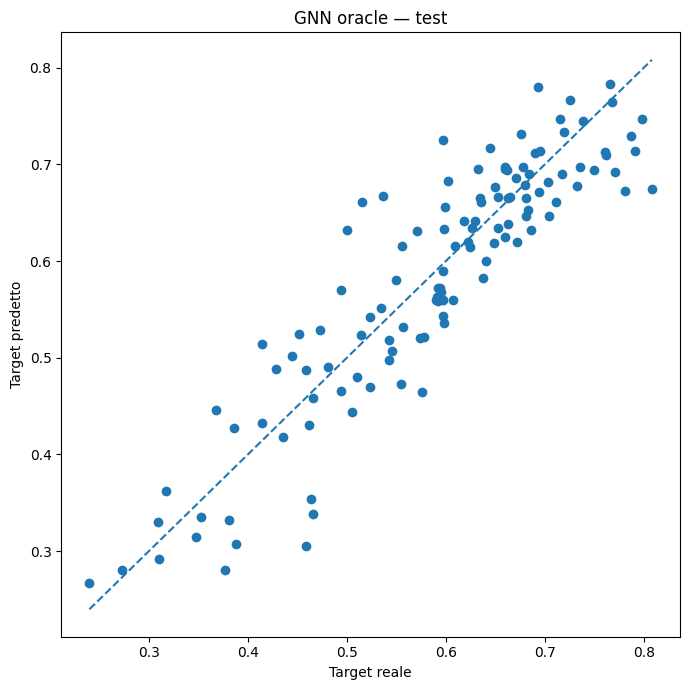

In [21]:
plt.figure(figsize=(7,7)); plt.scatter(test_predictions.target_true,test_predictions.target_predicted); mn=min(test_predictions.target_true.min(),test_predictions.target_predicted.min()); mx=max(test_predictions.target_true.max(),test_predictions.target_predicted.max()); plt.plot([mn,mx],[mn,mx],linestyle="--"); plt.xlabel("Target reale"); plt.ylabel("Target predetto"); plt.title("GNN oracle — test"); plt.tight_layout(); plt.savefig(REPORT_DIR/"test_true_vs_predicted.png",dpi=300,bbox_inches="tight"); plt.show()

## 18. Predizione del seed

In [22]:
seed_tensor=torch.tensor(encode_sequence(SEED_SEQUENCE)[None,...],dtype=torch.float32).to(DEVICE)
model.eval()
with torch.no_grad(): seed_scaled=float(model(seed_tensor).cpu().item())
seed_prediction=float(target_scaler.inverse_transform([[seed_scaled]])[0,0])
print("Target reale seed:",SEED_TARGET_VALUE)
print("Target predetto seed:",seed_prediction)
print("Errore assoluto:",abs(seed_prediction-SEED_TARGET_VALUE))

Target reale seed: 0.7586314868473996
Target predetto seed: 0.7459297705252568
Errore assoluto: 0.012701716322142786


## 19. Ranking delle varianti secondo l'oracolo

In [23]:
all_graph_dataset=PeptideGraphDataset(df,TARGET_COLUMN,target_scaler)
all_predictions=predict_dataframe(model,all_graph_dataset,df)
all_predictions["predicted_improvement_vs_seed"]=(all_predictions.target_predicted-seed_prediction) if HIGHER_IS_BETTER else (seed_prediction-all_predictions.target_predicted)
display(all_predictions[["variant_id","sequence","variant_type","mutation_labels","target_true","target_predicted","predicted_improvement_vs_seed"]].sort_values("predicted_improvement_vs_seed",ascending=False).head(30))

,variant_id,sequence,variant_type,mutation_labels,target_true,target_predicted,predicted_improvement_vs_seed
268,V00268,IGERSQYRELK,double,C5S;D9E,0.848590,0.841685,0.095755
206,V00206,IGERCQYKELK,double,R8K;D9E,0.816286,0.820839,0.074910
97,V00097,IGERCEYRELK,double,Q6E;D9E,0.797925,0.820120,0.074191
50,V00050,IGERCQYRELR,double,D9E;K11R,0.829395,0.813354,0.067425
25,V00025,IGERCQYRELK,single,D9E,0.836643,0.808900,0.062971
353,V00353,IGERCQYRELE,double,D9E;K11E,0.817938,0.807465,0.061535
254,V00254,IGERSEYRDLK,double,C5S;Q6E,0.801849,0.807358,0.061428
77,V00077,IGERCQYRELQ,double,D9E;K11Q,0.776086,0.803391,0.057461
327,V00327,IGERSQYKDLK,double,C5S;R8K,0.765596,0.794216,0.048286
441,V00441,IGERTQYRELK,double,C5T;D9E,0.801211,0.788197,0.042268


## 20. Salvataggio dell'oracolo

In [24]:
MODEL_PATH=MODEL_DIR/"clear_peptide_oracle_gnn.pt"
TARGET_SCALER_PATH=MODEL_DIR/"target_scaler.joblib"
RIDGE_PATH=MODEL_DIR/"ridge_baseline.joblib"
RF_PATH=MODEL_DIR/"random_forest_baseline.joblib"
CONFIG_PATH=MODEL_DIR/"oracle_config.json"
SPLITS_CSV=ORACLE_DIR/"dataset_splits.csv"
PREDICTIONS_CSV=ORACLE_DIR/"oracle_all_predictions.csv"
METRICS_CSV=ORACLE_DIR/"oracle_regression_metrics.csv"
CLASSIFICATION_CSV=ORACLE_DIR/"oracle_better_than_seed_metrics.csv"
HISTORY_CSV=ORACLE_DIR/"oracle_training_history.csv"
torch.save({"model_state_dict":model.state_dict(),"input_dim":NODE_FEATURE_DIM,"hidden_dim":HIDDEN_DIM,"message_passing_steps":MESSAGE_PASSING_STEPS,"dropout":DROPOUT,"sequence_length":SEQUENCE_LENGTH,"aa_alphabet":AA_ALPHABET,"target_column":TARGET_COLUMN,"higher_is_better":HIGHER_IS_BETTER,"seed_sequence":SEED_SEQUENCE,"seed_target_value":SEED_TARGET_VALUE,"seed_prediction":seed_prediction,"position_features":position_features,"property_mean":property_mean,"property_std":property_std,"chain_adjacency":CHAIN_ADJACENCY},MODEL_PATH)
joblib.dump(target_scaler,TARGET_SCALER_PATH); joblib.dump(baseline_models["Ridge"],RIDGE_PATH); joblib.dump(baseline_models["RandomForest"],RF_PATH)
split_export=pd.concat([train_df.assign(split="train"),val_df.assign(split="validation"),test_df.assign(split="test")],ignore_index=True)
split_export.to_csv(SPLITS_CSV,index=False); all_predictions.to_csv(PREDICTIONS_CSV,index=False); comparison_df.to_csv(METRICS_CSV,index=False); classification_metrics_df.to_csv(CLASSIFICATION_CSV,index=False); history_df.to_csv(HISTORY_CSV,index=False)
config={"seed_sequence":SEED_SEQUENCE,"target_column":TARGET_COLUMN,"higher_is_better":HIGHER_IS_BETTER,"seed_target_value":SEED_TARGET_VALUE,"seed_prediction":seed_prediction,"node_feature_dim":NODE_FEATURE_DIM,"hidden_dim":HIDDEN_DIM,"message_passing_steps":MESSAGE_PASSING_STEPS,"dropout":DROPOUT,"learning_rate":LEARNING_RATE,"weight_decay":WEIGHT_DECAY,"batch_size":BATCH_SIZE,"max_epochs":MAX_EPOCHS,"early_stopping_patience":EARLY_STOPPING_PATIENCE,"random_seed":RANDOM_SEED,"split_strategy":"GroupShuffleSplit by mutated positions","n_train":len(train_df),"n_validation":len(val_df),"n_test":len(test_df),"aa_alphabet":AA_ALPHABET}
CONFIG_PATH.write_text(json.dumps(config,indent=2),encoding="utf-8")
for p in [MODEL_PATH,TARGET_SCALER_PATH,RIDGE_PATH,RF_PATH,CONFIG_PATH,SPLITS_CSV,PREDICTIONS_CSV,METRICS_CSV,CLASSIFICATION_CSV,HISTORY_CSV]: print("Salvato:",p.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/models/clear_peptide_oracle_gnn.pt
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/models/target_scaler.joblib
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/models/ridge_baseline.joblib
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/models/random_forest_baseline.joblib
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/models/oracle_config.json
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/dataset_splits.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/oracle_all_predictions.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/oracle_regression_metrics.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/oracle_better_than_seed_metrics.csv
Salvato: /Users/robertobruzzese

## 21. Controllo minimo per procedere a CLEAR

In [25]:
test_gnn=gnn_metrics_df[gnn_metrics_df.split=="test"].iloc[0]
test_cls=classification_metrics_df[classification_metrics_df.split=="test"].iloc[0]
target_std=float(df[TARGET_COLUMN].std()); normalized_mae=float(test_gnn.MAE)/target_std if target_std>0 else np.nan
oracle_checks={"test_MAE":float(test_gnn.MAE),"target_std":target_std,"normalized_MAE":normalized_mae,"test_R2":float(test_gnn.R2),"test_Spearman":float(test_gnn.Spearman),"test_better_than_seed_F1":float(test_cls.f1),"seed_absolute_error":abs(seed_prediction-SEED_TARGET_VALUE)}
ORACLE_READY_PRELIMINARY=bool(np.isfinite(oracle_checks["test_Spearman"]) and oracle_checks["test_Spearman"]>0.40 and np.isfinite(normalized_mae) and normalized_mae<1.0)
print(json.dumps(oracle_checks,indent=2)); print("ORACLE_READY_PRELIMINARY:",ORACLE_READY_PRELIMINARY)

{
  "test_MAE": 0.044556792496285726,
  "target_std": 0.1261871446663091,
  "normalized_MAE": 0.35310088530897726,
  "test_R2": 0.8010358047386364,
  "test_Spearman": 0.8958948651944179,
  "test_better_than_seed_F1": 0.2857142857142857,
  "seed_absolute_error": 0.012701716322142786
}
ORACLE_READY_PRELIMINARY: True


## 22. Report automatico

In [26]:
report=f"""# 04d — CLEAR peptide oracle report

## Dataset
- Input: `{dataset_path}`
- Target: `{TARGET_COLUMN}`
- Higher is better: {HIGHER_IS_BETTER}
- Train: {len(train_df)}
- Validation: {len(val_df)}
- Test: {len(test_df)}

## Seed
- Sequenza: `{SEED_SEQUENCE}`
- Target reale: {SEED_TARGET_VALUE:.6f}
- Target predetto: {seed_prediction:.6f}
- Errore assoluto: {abs(seed_prediction-SEED_TARGET_VALUE):.6f}

## GNN test
- MAE: {test_gnn.MAE:.6f}
- RMSE: {test_gnn.RMSE:.6f}
- R²: {test_gnn.R2:.6f}
- Pearson: {test_gnn.Pearson:.6f}
- Spearman: {test_gnn.Spearman:.6f}

## Classificazione better-than-seed
- Accuracy: {test_cls.accuracy:.6f}
- Precision: {test_cls.precision:.6f}
- Recall: {test_cls.recall:.6f}
- F1: {test_cls.f1:.6f}

## Controllo preliminare
- ORACLE_READY_PRELIMINARY: {ORACLE_READY_PRELIMINARY}

## Modello
`{MODEL_PATH}`
"""
REPORT_PATH=REPORT_DIR/"04d_oracle_report.md"; REPORT_PATH.write_text(report,encoding="utf-8"); print(report); print("Report salvato:",REPORT_PATH.resolve())

# 04d — CLEAR peptide oracle report

## Dataset
- Input: `outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv`
- Target: `oracle_target_composite_preliminary`
- Higher is better: True
- Train: 306
- Validation: 112
- Test: 121

## Seed
- Sequenza: `IGERCQYRDLK`
- Target reale: 0.758631
- Target predetto: 0.745930
- Errore assoluto: 0.012702

## GNN test
- MAE: 0.044557
- RMSE: 0.055835
- R²: 0.801036
- Pearson: 0.903827
- Spearman: 0.895895

## Classificazione better-than-seed
- Accuracy: 0.917355
- Precision: 0.500000
- Recall: 0.200000
- F1: 0.285714

## Controllo preliminare
- ORACLE_READY_PRELIMINARY: True

## Modello
`outputs/clear_peptide_oracle_04d/models/clear_peptide_oracle_gnn.pt`

Report salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/reports/04d_oracle_report.md


## 23. Output principali

```text
outputs/clear_peptide_oracle_04d/
    models/clear_peptide_oracle_gnn.pt
    models/target_scaler.joblib
    models/oracle_config.json
    dataset_splits.csv
    oracle_all_predictions.csv
    oracle_regression_metrics.csv
    oracle_better_than_seed_metrics.csv
    reports/04d_oracle_report.md
```

Il file `clear_peptide_oracle_gnn.pt` contiene anche adjacency, proprietà normalizzate, feature posizionali, target e valore del seed. Questi dati saranno caricati direttamente dal notebook 04e.